Dieser Code trainiert und evaluiert zwei Naive Bayes Modelle mit der Vektorisierung TF-IDF anhand dieses Datensatzes:

    @inproceedings{tonneau-etal-2024-languages,

    title = "From Languages to Geographies: Towards Evaluating Cultural Bias in Hate Speech Datasets",

    author = {Tonneau, Manuel  and
      Liu, Diyi  and
      Fraiberger, Samuel  and
      Schroeder, Ralph  and
      Hale, Scott  and
      Röttger, Paul},
    editor = {Chung, Yi-Ling  and
      Talat, Zeerak  and
      Nozza, Debora  and
      Plaza-del-Arco, Flor Miriam  and
      Röttger, Paul  and
      Mostafazadeh Davani, Aida  and
      Calabrese, Agostina},
    
    booktitle = "Proceedings of the 8th Workshop on Online Abuse and Harms (WOAH 2024)",
    month = jun,
    year = "2024",
    address = "Mexico City, Mexico",
    publisher = "Association for Computational Linguistics",
    url = "https://aclanthology.org/2024.woah-1.23",
    pages = "283--311",
    abstract = "Perceptions of hate can vary greatly across cultural contexts.
    Hate speech (HS) datasets, however, have traditionally been developed by
    language. This hides potential cultural biases, as one language may be
    spoken in different countries home to different cultures. In this work, we
    evaluate cultural bias in HS datasets by leveraging two interrelated
    cultural proxies: language and geography. We conduct a systematic survey
    of HS datasets in eight languages and confirm past findings on their
    English-language bias, but also show that this bias has been steadily
    decreasing in the past few years. For three geographically-widespread
    languages{---}English, Arabic and Spanish{---}we then leverage
    geographical metadata from tweets to approximate geo-cultural contexts by
    pairing language and country information. We find that HS datasets for
    these languages exhibit a strong geo-cultural bias, largely
    overrepresenting a handful of countries (e.g., US and UK for English)
    relative to their prominence in both the broader social media population
    and the general population speaking these languages. Based on these
    findings, we formulate recommendations for the creation of future HS
    datasets.",}
Die Vektorisierung erfoglt über TF-IDF.



Imports

In [1]:
 import pandas as pd
 import matplotlib.pyplot  as plt
 import seaborn as sns
 import numpy as np
 import sklearn
 import sklearn.metrics as metrics


In [2]:
import nltk
nltk.download("stopwords")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [3]:
from nltk.corpus import stopwords
german_stopwords=stopwords.words("german")

In [5]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


# Dateninitialisierung

In [6]:
#Datensatz importieren

df = pd.read_csv(
    "/content/drive/MyDrive/Colab Notebooks/de_hf_112024.csv",sep=",",engine="python",on_bad_lines="skip",encoding="utf-8")
df.head()


,text,labels,source,dataset,nb_annotators
0,gleich an die wand stellen und erschiessen..,1.0,Facebook,Bretschneider,2.0
1,nicht dass ich der Grundbotschaft dieses Post'...,0.0,Facebook,Bretschneider,2.0
2,"Das mit dem ""an die Wand stellen und erschiessen""",0.0,Facebook,Bretschneider,2.0
3,"Seit dem ""an die Wand stellen und erschiessen""...",0.0,Facebook,Bretschneider,2.0
4,Ja ja die Kriminelle Heimatpartei FPÖ von Kind...,0.0,Facebook,Bretschneider,2.0


In [7]:
df["labels"].isna().sum()
df[df["labels"].isna()]


,text,labels,source,dataset,nb_annotators
2519,Das macht Angst....,NaN,None,None,NaN


In [8]:
df=df.dropna(subset=["labels"])

In [9]:
df["labels"].isna().sum()

np.int64(0)

# Datensatzaufteilung

In [10]:
from sklearn.model_selection import train_test_split
X=df["text"]
y=df["labels"].astype(int)

In [46]:
#TRAIN /TEST
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
#TRAIN / VALIDATION
X_train, X_val, y_train, y_val = train_test_split( X_train, y_train, test_size=0.1, random_state=42)

# Naive Bayes mit TF-IDF-Unigramm

In [47]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf=TfidfVectorizer(
    lowercase=True,
    stop_words=german_stopwords,
    ngram_range=(1,1))


X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf   = tfidf.transform(X_val)
X_test_tfidf  = tfidf.transform(X_test)

In [48]:
from sklearn.naive_bayes import MultinomialNB

modelTFIDF=MultinomialNB()
modelTFIDF.fit(X_train_tfidf,y_train)

MultinomialNB()

In [49]:
y_val_pred=modelTFIDF.predict(X_val_tfidf)
y_val_proba=modelTFIDF.predict_proba(X_val_tfidf)[:,1] #[2 spaltrige matrix spalte 0 K hasskomennte/ spalte 1 hasskoemmtar]

#wahrscheinlichkeiten in datei schreiben
with open("naive_bayes_TF-IDF.txt", "w") as fd:
  for text, labels, proba in zip(X_val,y_val, y_val_proba):
    fd.write(f"Text: {text}\n")
    fd.write(f"Label: {labels}\n")
    fd.write(f"Wahrscheinlichkeit Hasskommentar: {proba}\n")
    fd.write("\n"*4)
#beste Klassifikationsschwelle finden
schwelle = np.arange(0.0,1.01,0.01)
beste_schwelle = 0
beste_f1 = 0

for t in schwelle:
  y_val_pred_schwelle = np.where(y_val_proba > t, 1, 0)
  f1 = metrics.f1_score(y_val, y_val_pred_schwelle)
  if f1 > beste_f1:
    beste_f1 = f1
    beste_schwelle = t
    print("Beste Schwelle: ", beste_schwelle)
    print("Bester F1 Score: ", beste_f1)

print("Final beste Schwelle: ", beste_schwelle)
print("Bester F1 Score: ", beste_f1)

Beste Schwelle:  0.0
Bester F1 Score:  0.2185022026431718
Beste Schwelle:  0.01
Bester F1 Score:  0.29968119022316686
Beste Schwelle:  0.02
Bester F1 Score:  0.35645472061657035
Beste Schwelle:  0.03
Bester F1 Score:  0.39424805272618335
Beste Schwelle:  0.04
Bester F1 Score:  0.41040462427745666
Beste Schwelle:  0.05
Bester F1 Score:  0.4105960264900662
Beste Schwelle:  0.06
Bester F1 Score:  0.4202764976958525
Final beste Schwelle:  0.06
Bester F1 Score:  0.4202764976958525


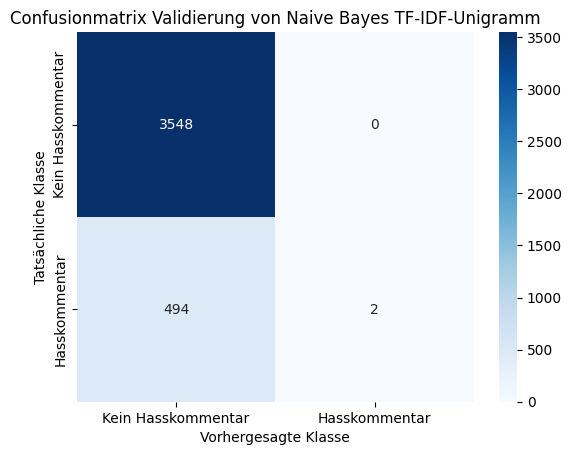

In [24]:
# Confusion Matrix

cm = metrics.confusion_matrix(y_val, y_val_pred)
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Kein Hasskommentar","Hasskommentar"],
    yticklabels=["Kein Hasskommentar","Hasskommentar"]
)
plt.title("Confusion Matrix Validierung von Naive Bayes TF-IDF-Unigramm")
plt.xlabel("Vorhergesagte Klasse")
plt.ylabel("Tatsächliche Klasse")
plt.show()

In [50]:
# accuracy
vaccuracy = metrics.accuracy_score(y_val, y_val_pred)
# precision
vprecision = metrics.precision_score(y_val, y_val_pred)
# recall
vrecall = metrics.recall_score(y_val, y_val_pred)
# f1-score
vf1=metrics.f1_score(y_val, y_val_pred)
# specificity
tn, fp, fn, tp = metrics.confusion_matrix(y_val, y_val_pred).ravel()
vspecificity = tn/(tn+fp)
# macro recall
vmacro_recall=metrics.recall_score(y_val, y_val_pred, average='macro')
# macro f1-score
vmacro_f1=metrics.f1_score(y_val, y_val_pred, average='macro')

In [51]:
print("Accuracy: ", vaccuracy)
print("Precision: ", vprecision)
print("Recall: ", vrecall)
print("Specificity: ", vspecificity)
print("F1-Score: ", vf1)
print("Macro Recall: ", vmacro_recall)
print("Macro F1-Score: ", vmacro_f1)

Accuracy:  0.8778437190900099
Precision:  1.0
Recall:  0.004032258064516129
Specificity:  1.0
F1-Score:  0.008032128514056224
Macro Recall:  0.5020161290322581
Macro F1-Score:  0.47147324475768687


**Testen mit Standardschwellenwert**

In [52]:
y_pred=modelTFIDF.predict(X_test_tfidf)

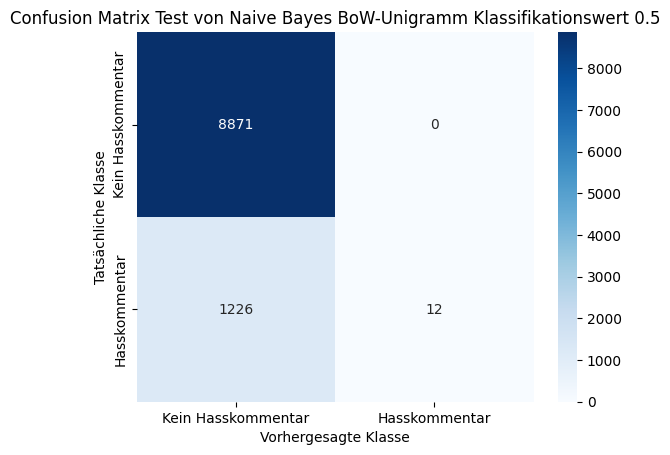

In [53]:
# Confusion Matrix

cm = metrics.confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Kein Hasskommentar","Hasskommentar"],
    yticklabels=["Kein Hasskommentar","Hasskommentar"]
)
plt.title("Confusion Matrix Test von Naive Bayes BoW-Unigramm Klassifikationswert 0.5")
plt.xlabel("Vorhergesagte Klasse")
plt.ylabel("Tatsächliche Klasse")
plt.show()

In [54]:
# accuracy
accuracy = metrics.accuracy_score(y_test, y_pred)
# precision
precision = metrics.precision_score(y_test, y_pred)
# recall
recall = metrics.recall_score(y_test, y_pred)
# f1-score
f1=metrics.f1_score(y_test, y_pred)
# specificity
tn, fp, fn, tp = metrics.confusion_matrix(y_test, y_pred).ravel()
specificity = tn/(tn+fp)
# macro recall
macro_recall=metrics.recall_score(y_test, y_pred, average='macro')
# macro f1-score
macro_f1=metrics.f1_score(y_test, y_pred, average='macro')

In [55]:
print("Accuracy: ", accuracy)
print("Precision: ", precision)
print("Recall: ", recall)
print("Specificity: ", specificity)
print("F1-Score: ", f1)
print("Macro Recall: ", macro_recall)
print("Macro F1-Score: ", macro_f1)

Accuracy:  0.8787219309526165
Precision:  1.0
Recall:  0.009693053311793215
Specificity:  1.0
F1-Score:  0.0192
Macro Recall:  0.5048465266558966
Macro F1-Score:  0.4772824124841839


In [21]:
#Modell speichern
import joblib
joblib.dump(modelTFIDF,"/content/drive/MyDrive/Colab Notebooks/naive_bayes_TF-IDF_model.plk")

['/content/drive/MyDrive/Colab Notebooks/naive_bayes_TF-IDF_model.plk']

**mit optimalen Wert**

In [56]:
y_test_proba=modelTFIDF.predict_proba(X_test_tfidf)[:,1] # mit schwellen wert
y_test_pred_opt=(y_test_proba>beste_schwelle).astype(int) # mit optimaler schwellen wert

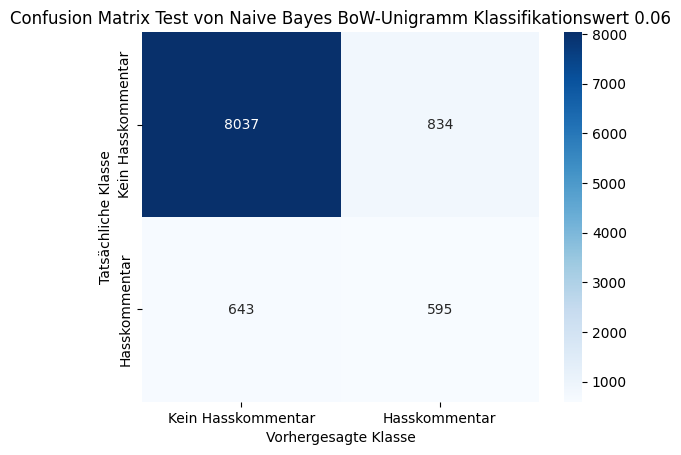

In [57]:
# Confusion Matrix

cm = metrics.confusion_matrix(y_test,y_test_pred_opt)
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Kein Hasskommentar","Hasskommentar"],
    yticklabels=["Kein Hasskommentar","Hasskommentar"]
)
plt.title("Confusion Matrix Test von Naive Bayes BoW-Unigramm Klassifikationswert 0.06")
plt.xlabel("Vorhergesagte Klasse")
plt.ylabel("Tatsächliche Klasse")
plt.show()

In [58]:
# accuracy
accuracy = metrics.accuracy_score(y_test, y_test_pred_opt)
# precision
precision = metrics.precision_score(y_test,  y_test_pred_opt)
# recall
recall = metrics.recall_score(y_test,  y_test_pred_opt)
# f1-score
f1=metrics.f1_score(y_test,  y_test_pred_opt)
# specificity
tn, fp, fn, tp = metrics.confusion_matrix(y_test,  y_test_pred_opt).ravel()
specificity = tn/(tn+fp)
# macro recall
macro_recall=metrics.recall_score(y_test,  y_test_pred_opt, average='macro')
# macro f1-score
macro_f1=metrics.f1_score(y_test, y_test_pred_opt, average='macro')

In [59]:
print("Accuracy: ", accuracy)
print("Precision: ", precision)
print("Recall: ", recall)
print("Specificity: ", specificity)
print("F1-Score: ", f1)
print("Macro Recall: ", macro_recall)
print("Macro F1-Score: ", macro_f1)

Accuracy:  0.8538925709763577
Precision:  0.4163750874737579
Recall:  0.4806138933764136
Specificity:  0.9059857964152858
F1-Score:  0.4461942257217848
Macro Recall:  0.6932998448958496
Macro F1-Score:  0.6810197383523173


#Naive Bayes TF-IDF Bigramm ohne Stoppwortentfernung

In [60]:
print("Merkmal Anzahl in X_train", X_train_tfidf.shape)
row = X_train_tfidf[0].toarray()[0]
print("Anteil Nullwerte:", np.mean(row == 0))
print("Min TF-IDF:", row[row>0].min())
print("Max TF-IDF:", row.max())

Merkmal Anzahl in X_train (36390, 73183)
Anteil Nullwerte: 0.9998496918683301
Min TF-IDF: 0.21853949560815666
Max TF-IDF: 0.36161707671342025


In [61]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf=TfidfVectorizer(
    lowercase=True,
    ngram_range=(1,2))


X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf   = tfidf.transform(X_val)
X_test_tfidf  = tfidf.transform(X_test)

In [62]:
from sklearn.naive_bayes import MultinomialNB

modelTFIDFohneStopp=MultinomialNB()
modelTFIDFohneStopp.fit(X_train_tfidf,y_train)

MultinomialNB()

In [63]:
y_val_pred=modelTFIDFohneStopp.predict(X_val_tfidf)
y_val_proba=modelTFIDFohneStopp.predict_proba(X_val_tfidf)[:,1] #[2 spaltrige matrix spalte 0 K hasskomennte/ spalte 1 hasskoemmtar]

#wahrscheinlichkeiten in datei schreiben
with open("naive_bayes_TF-IDF_ohneStopp.txt", "w") as fd:
  for text, labels, proba in zip(X_val,y_val, y_val_proba):
    fd.write(f"Text: {text}\n")
    fd.write(f"Label: {labels}\n")
    fd.write(f"Wahrscheinlichkeit Hasskommentar: {proba}\n")
    fd.write("\n"*4)
#beste Klassifikationsschwelle finden
schwelle = np.arange(0.0,1.01,0.01)
beste_schwelle = 0
beste_f1 = 0

for t in schwelle:
  y_val_pred_schwelle = np.where(y_val_proba > t, 1, 0)
  f1 = metrics.f1_score(y_val, y_val_pred_schwelle)
  if f1 > beste_f1:
    beste_f1 = f1
    beste_schwelle = t
    print("Beste Schwelle: ", beste_schwelle)
    print("Bester F1 Score: ", beste_f1)

print("Final beste Schwelle: ", beste_schwelle)
print("Bester F1 Score: ", beste_f1)

Beste Schwelle:  0.0
Bester F1 Score:  0.2185022026431718
Beste Schwelle:  0.01
Bester F1 Score:  0.3642329778506973
Final beste Schwelle:  0.01
Bester F1 Score:  0.3642329778506973


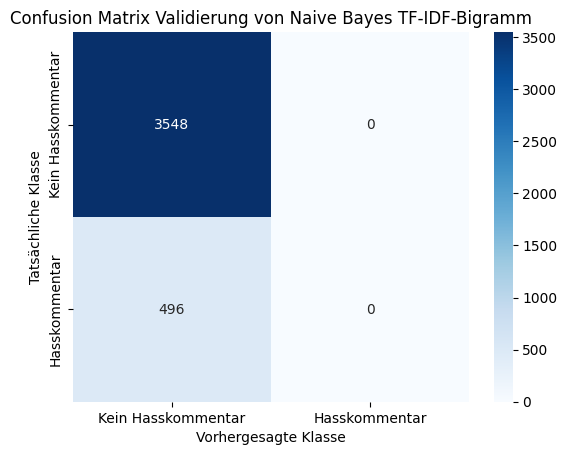

In [64]:
# Confusion Matrix

cm = metrics.confusion_matrix(y_val, y_val_pred)
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Kein Hasskommentar","Hasskommentar"],
    yticklabels=["Kein Hasskommentar","Hasskommentar"]
)
plt.title("Confusion Matrix Validierung von Naive Bayes TF-IDF-Bigramm")
plt.xlabel("Vorhergesagte Klasse")
plt.ylabel("Tatsächliche Klasse")
plt.show()

In [65]:
# accuracy
vaccuracy = metrics.accuracy_score(y_val, y_val_pred)
# precision
vprecision = metrics.precision_score(y_val, y_val_pred)
# recall
vrecall = metrics.recall_score(y_val, y_val_pred)
# f1-score
vf1=metrics.f1_score(y_val, y_val_pred)
# specificity
tn, fp, fn, tp = metrics.confusion_matrix(y_val, y_val_pred).ravel()
vspecificity = tn/(tn+fp)
# macro recall
vmacro_recall=metrics.recall_score(y_val, y_val_pred, average='macro')
# macro f1-score
vmacro_f1=metrics.f1_score(y_val, y_val_pred, average='macro')

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [66]:
print("Accuracy: ", vaccuracy)
print("Precision: ", vprecision)
print("Recall: ", vrecall)
print("Specificity: ", vspecificity)
print("F1-Score: ", vf1)
print("Macro Recall: ", vmacro_recall)
print("Macro F1-Score: ", vmacro_f1)

Accuracy:  0.8773491592482691
Precision:  0.0
Recall:  0.0
Specificity:  1.0
F1-Score:  0.0
Macro Recall:  0.5
Macro F1-Score:  0.4673340358271865


**Testen mit Standardschwellenwert**

In [67]:
y_pred=modelTFIDFohneStopp.predict(X_test_tfidf)

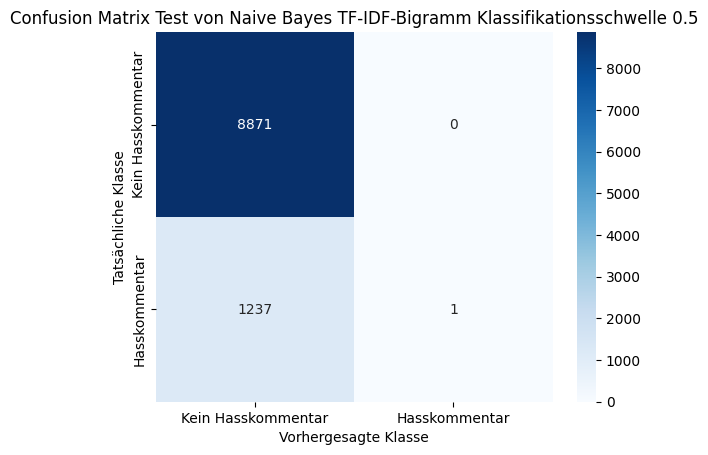

In [44]:
# Confusion Matrix

cm = metrics.confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm,
    annot=True, #zeigt werte an, annotation
    fmt="d", # integer gibt ganze zahl an, sonst mit nachkommastellen
    cmap="Blues",# farbpalette, helle farbe = kleiner wert / dunkle farbe = hoher wert
    xticklabels=["Kein Hasskommentar","Hasskommentar"], #beschriftung der x achse
    yticklabels=["Kein Hasskommentar","Hasskommentar"] #beschriftung y achse
)
plt.title("Confusion Matrix Test von Naive Bayes TF-IDF-Bigramm Klassifikationsschwelle 0.5")
plt.xlabel("Vorhergesagte Klasse")
plt.ylabel("Tatsächliche Klasse")
plt.show()

In [68]:
# accuracy
accuracy = metrics.accuracy_score(y_test, y_pred)
# precision
precision = metrics.precision_score(y_test, y_pred)
# recall
recall = metrics.recall_score(y_test, y_pred)
# f1-score
f1=metrics.f1_score(y_test, y_pred)
# specificity
tn, fp, fn, tp = metrics.confusion_matrix(y_test, y_pred).ravel()
specificity = tn/(tn+fp)
# macro recall
macro_recall=metrics.recall_score(y_test, y_pred, average='macro')
# macro f1-score
macro_f1=metrics.f1_score(y_test, y_pred, average='macro')

In [69]:
print("Accuracy: ", accuracy)
print("Precision: ", precision)
print("Recall: ", recall)
print("Specificity: ", specificity)
print("F1-Score: ", f1)
print("Macro Recall: ", macro_recall)
print("Macro F1-Score: ", macro_f1)

Accuracy:  0.8776337916707884
Precision:  1.0
Recall:  0.0008077544426494346
Specificity:  1.0
F1-Score:  0.0016142050040355124
Macro Recall:  0.5004038772213247
Macro F1-Score:  0.4682184518881814


In [48]:
#Modell speichern
import joblib
joblib.dump(modelTFIDF,"/content/drive/MyDrive/Colab Notebooks/naive_bayes_TF-IDF_ohneStopp_model.plk")

['/content/drive/MyDrive/Colab Notebooks/naive_bayes_TF-IDF_ohneStopp_model.plk']

**optimierter Schwellenwert**

In [49]:
y_test_proba=modelTFIDFohneStopp.predict_proba(X_test_tfidf)[:,1] # mit schwellen wert
y_test_pred_opt=(y_test_proba>beste_schwelle).astype(int) # mit optimaler schwellen wert

AttributeError: module 'matplotlib' has no attribute 'title'

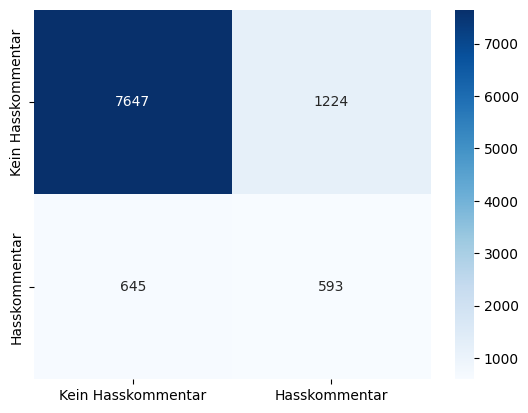

In [51]:
# Confusion Matrix

cm = metrics.confusion_matrix(y_test, y_test_pred_opt)
sns.heatmap(
    cm,
    annot=True, #zeigt werte an, annotation
    fmt="d", # integer gibt ganze zahl an, sonst mit nachkommastellen
    cmap="Blues",# farbpalette, helle farbe = kleiner wert / dunkle farbe = hoher wert
    xticklabels=["Kein Hasskommentar","Hasskommentar"], #beschriftung der x achse
    yticklabels=["Kein Hasskommentar","Hasskommentar"] #beschriftung y achse
)
plt.title("Confusionmatrix Test von Naive Bayes TF-IDF-Bigramm Klassifikationsschwelle 0.01")
plt.xlabel("Vorhergesagte Klasse")
plt.ylabel("Tatsächliche Klasse")
plt.show()

In [52]:
# accuracy
accuracy = metrics.accuracy_score(y_test, y_test_pred_opt)
# precision
precision = metrics.precision_score(y_test,  y_test_pred_opt)
# recall
recall = metrics.recall_score(y_test,  y_test_pred_opt)
# f1-score
f1=metrics.f1_score(y_test,  y_test_pred_opt)
# specificity
tn, fp, fn, tp = metrics.confusion_matrix(y_test,  y_test_pred_opt).ravel()
specificity = tn/(tn+fp)
# macro recall
macro_recall=metrics.recall_score(y_test,  y_test_pred_opt, average='macro')
# macro f1-score
macro_f1=metrics.f1_score(y_test, y_test_pred_opt, average='macro')

In [53]:
print("Accuracy: ", accuracy)
print("Precision: ", precision)
print("Recall: ", recall)
print("Specificity: ", specificity)
print("F1-Score: ", f1)
print("Macro Recall: ", macro_recall)
print("Macro F1-Score: ", macro_f1)

Accuracy:  0.8151152438421209
Precision:  0.3263621353880022
Recall:  0.4789983844911147
Specificity:  0.8620223199188367
F1-Score:  0.3882160392798691
Macro Recall:  0.6705103522049757
Macro F1-Score:  0.6396594966544425
